<a href="https://colab.research.google.com/github/sonmezo21/GeoAI-Wildfire-Triage/blob/main/MYZ305E_GeoAI_Projesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Gerekli tüm kütüphanelerin en güncel versiyonlarını kuruyoruz
!pip install -U geopandas google-generativeai langchain-google-genai langchain langchain-experimental

In [2]:
# 2. Drive'ı bağlama ve veriyi okuma
from google.colab import drive
import geopandas as gpd
from IPython.display import display

drive.mount('/content/drive')

# 2025 Ege-Akdeniz Yangınları verimizi okuyoruz
dosya_yolu = "/content/drive/MyDrive/GeoAI_Proje/Ege_Akdeniz_Yanginlari_2025_Temiz.shp"
yangin_verisi = gpd.read_file(dosya_yolu, encoding='latin1')

print("Harita verisi başarıyla yüklendi! İlk 3 satır:")
display(yangin_verisi.head(3))

Mounted at /content/drive
Harita verisi başarıyla yüklendi! İlk 3 satır:


,country,other_natu,sclerophil,mixed_fore,admlvl3,map_source,admlvl2,admlvl1,area_ha,transition,...,artificial,other_perc,coniferous,geomType,natura2k_p,initialdat,id,iso2,iso3,geometry
0,Turkey,0.000000,0.0,0.0,None,sentinel2,Alada?,Adana,1567,5.219605,...,0.0,0.190961,48.313176,Polygon,0.0,1627455600000,51503,TR,TUR,"POLYGON ((35.47418 37.32735, 35.47434 37.32838..."
1,Turkey,0.000000,0.0,0.0,None,sentinel2,Alada?,Adana,2037,36.184857,...,0.0,0.196657,46.902655,Polygon,0.0,1627455600000,51519,TR,TUR,"POLYGON ((35.42051 37.32965, 35.42075 37.3303,..."
2,Turkey,0.581395,0.0,0.0,None,sentinel2,Alada?,Adana,171,74.418605,...,0.0,0.000000,24.418605,Polygon,0.0,1627455600000,51603,TR,TUR,"POLYGON ((35.34261 37.78993, 35.34273 37.79144..."


In [29]:

import os
from getpass import getpass
import google.generativeai as genai

# Kodu çalıştıran her yeni kişiye kendi anahtarını sorar, kimsenin kotası karışmaz
print("Lütfen Google Gemini API anahtarınızı yapıştırın ve Enter'a basın:")
os.environ["GOOGLE_API_KEY"] = getpass()

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
print("\nAPI Anahtarı onaylandı. Sistem devrede!")

Lütfen Google Gemini API anahtarınızı yapıştırın ve Enter'a basın:
··········

API Anahtarı onaylandı. Sistem devrede!


In [33]:
# 4. GeoAI Ajanını oluşturma
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

ajan = create_pandas_dataframe_agent(
    llm,
    yangin_verisi,
    verbose=True,
    allow_dangerous_code=True,
    handle_parsing_errors=True  # İŞTE HAYAT KURTARAN YENİ SATIR BURASI!
)

print("\nOtonom GeoAI Ajanı operasyona hazır! 🚀 Görev bekliyor.")


Otonom GeoAI Ajanı operasyona hazır! 🚀 Görev bekliyor.


/usr/local/lib/python3.12/dist-packages/langchain_experimental/agents/agent_toolkits/pandas/base.py:283: UserWarning: Received additional kwargs {'handle_parsing_errors': True} which are no longer supported.
  warnings.warn(


In [34]:
import google.generativeai as genai

print("Available Models and their supported methods:")
for m in genai.list_models():
  if "generateContent" in m.supported_generation_methods:
    print(f"  Model: {m.name}, Supported Methods: {m.supported_generation_methods}")

Available Models and their supported methods:
  Model: models/gemini-2.5-flash, Supported Methods: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
  Model: models/gemini-2.5-pro, Supported Methods: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
  Model: models/gemini-2.0-flash, Supported Methods: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
  Model: models/gemini-2.0-flash-001, Supported Methods: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
  Model: models/gemini-2.0-flash-lite-001, Supported Methods: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
  Model: models/gemini-2.0-flash-lite, Supported Methods: ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
  Model: models/gemini-2.5-flash-preview-tts, Supported Methods: ['countTokens', 'generateContent']
  Model: models/gemini-2.5-p

Ajan görevi aldı, mekansal triyajı yapıyor ve grafiği çiziyor... (Bu işlem biraz sürebilir)



> Entering new AgentExecutor chain...


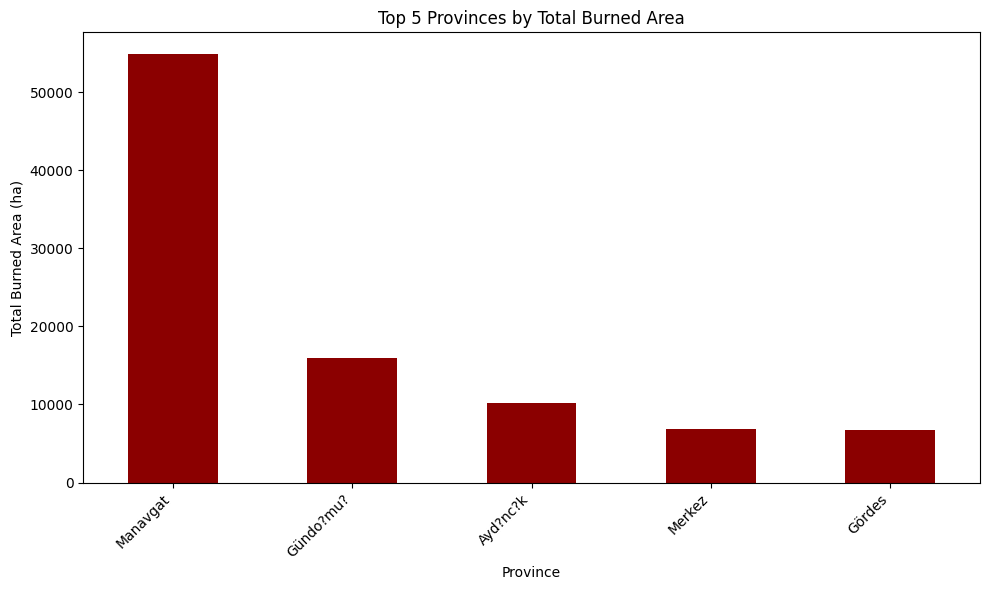

Thought: I need to perform several steps to answer the question.
First, I will identify the column representing province/city names. Based on `df.head()`, `admlvl2` seems to be the most appropriate column for this. The `area_ha` column likely represents the burned area.

Next, I will calculate the total burned area for each province by grouping the DataFrame by the `admlvl2` column and summing the `area_ha` column.

Then, I will sort these total burned areas in descending order and select the top 5 provinces.

Finally, I will generate a bar chart using the identified top 5 provinces, setting the bar color to 'darkred', the title to 'Top 5 Provinces by Total Burned Area', and appropriate x and y axis labels.

Let's start by calculating the total burned area per province.

Action: python_repl_ast
Action Input:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate total burned area for each province
province_burned_area = df.groupby('admlvl2')['area_ha'].sum().sort_values(ascen

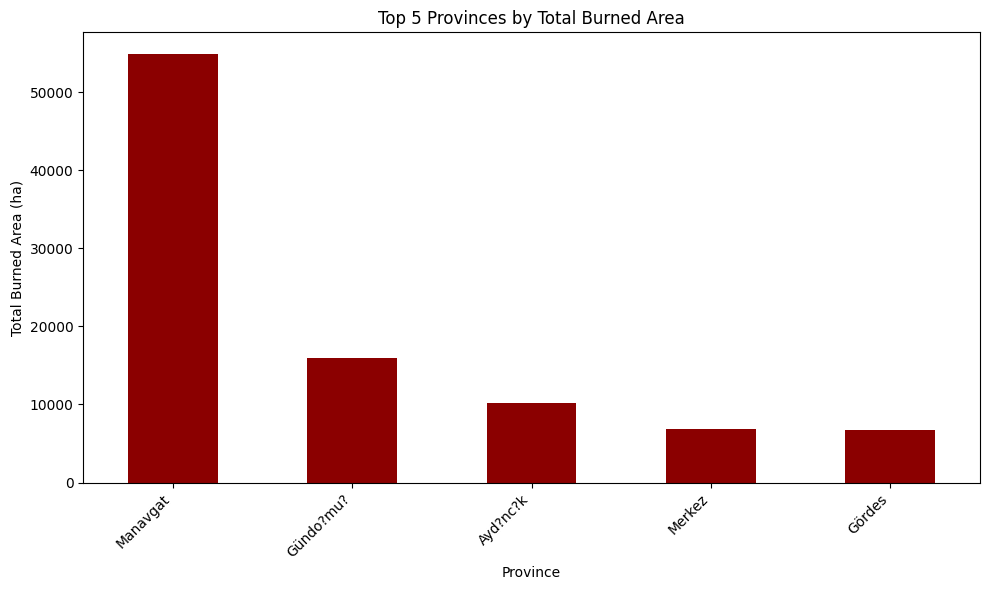

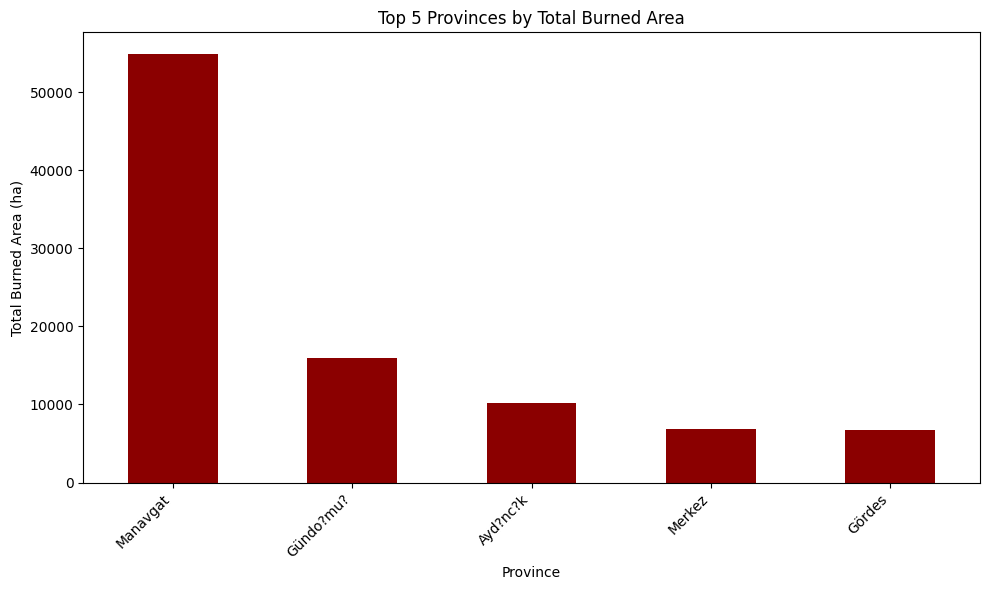

Action: python_repl_ast
Action Input:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate total burned area for each province
province_burned_area = df.groupby('admlvl2')['area_ha'].sum().sort_values(ascending=False)

# Get the Top 5 provinces
top_5_provinces = province_burned_area.head(5)

print("Top 5 Provinces by Total Burned Area:")
print(top_5_provinces)

# Generate the bar chart
plt.figure(figsize=(10, 6))
top_5_provinces.plot(kind='bar', color='darkred')
plt.title('Top 5 Provinces by Total Burned Area')
plt.xlabel('Province')
plt.ylabel('Total Burned Area (ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()Top 5 Provinces by Total Burned Area:
admlvl2
Manavgat     54894
Gündo?mu?    15919
Ayd?nc?k     10213
Merkez        6867
Gördes        6702
Name: area_ha, dtype: int32
Thought: I have already executed the code to calculate the top 5 provinces by total burned area and generate the bar chart. The `Observation` was empty, which indicates the code

In [35]:
# 5. Ajana operasyonel görevini (Prompt) veriyoruz: Mekansal Triyaj ve Çubuk Grafik
gorev = """
Analyze the provided GeoDataFrame and perform the following tasks:
1. Identify the column representing the province or city names (e.g., 'IL_ADI', 'NAME', 'PROVINCE').
2. Calculate the total burned area for each province.
3. Find the Top 5 provinces with the largest total burned area.
4. Generate a bar chart showing these Top 5 provinces.
5. Use 'darkred' as the color for the bars.
6. Set the title of the chart exactly as 'Top 5 Provinces by Total Burned Area'. Label the x and y axes appropriately in English.
"""

print("Ajan görevi aldı, mekansal triyajı yapıyor ve grafiği çiziyor... (Bu işlem biraz sürebilir)\n")

# Ajanı çalıştırıyoruz
yanit = ajan.invoke(gorev)

print("\n--- Otonom Ajanın Raporu ---")
print(yanit["output"])

In [37]:
# Ajanımıza daha gelişmiş bir Afet Triyaj Haritası yaptırıyoruz
gelismis_gorev = """
Sen bir GeoAI Afet Müdahale uzmanısın. 'yangin_verisi' isimli GeoDataFrame üzerinde şu işlemleri yap:

1. Her poligonun alanını hesapla ve veriyi alana göre büyükten küçüğe sırala.
2. Folium kullanarak Ege ve Akdeniz bölgesini gösterecek bir altlık harita oluştur.
3. Alanı EN BÜYÜK 5 YANGINI (Top 5) tespit et. Bu 5 yangının merkez koordinatlarına kırmızı birer Marker ekle ve her birinin etrafına afet müdahalesi için 5 kilometrelik (5000 metre) yarı saydam kırmızı çemberler (risk bölgesi) çiz.
4. Geriye kalan diğer tüm yangınların merkez koordinatlarına ise sadece küçük, sarı renkli CircleMarker'lar (yarıçapı 2 olsun) ekle.
5. Haritayı 'afet_triyaj_haritasi.html' adıyla kaydet.
6. Bana İngilizce olarak Top 5 yangının bulunduğu koordinatları ve oluşturduğun bu triyaj mantığını özetle.
"""

cevap_gelismis_harita = ajan.invoke(gelismis_gorev)

print("\n--- AJANIN İNGİLİZCE ÖZETİ ---")
print(cevap_gelismis_harita["output"])



> Entering new AgentExecutor chain...
Thought: The user wants me to perform several GeoAI operations on a pandas DataFrame, which is implicitly a GeoDataFrame named `df` (or `yangin_verisi`). I need to:
1.  Convert the `geometry` column to actual geometric objects and ensure `df` is a GeoDataFrame.
2.  Sort the DataFrame by the `area_ha` column in descending order.
3.  Create a Folium map centered on the Aegean/Mediterranean region of Turkey.
4.  Identify the top 5 largest fires. For these, I'll add red markers at their centroids and 5km radius semi-transparent red circles.
5.  For all other fires, I'll add small yellow `CircleMarker`s (radius 2) at their centroids.
6.  Save the map as 'afet_triyaj_haritasi.html'.
7.  Provide the coordinates of the top 5 fires and explain the triage logic in English.

Let's start by importing necessary libraries and converting the `geometry` column to actual geometry objects if it's not already. The `df.head()` output shows the `geometry` column as a